1. Loading data...
2. Engineering Features (Adding Time & Aggregations)...
Features: 522
Converting categories...
3. Starting Training with New Features...


Default metric period is 5 because MAE is/are not implemented for GPU


0:	learn: 0.4814470	test: 0.5070823	best: 0.5070823 (0)	total: 233ms	remaining: 19m 23s
1000:	learn: 0.1464586	test: 0.2635150	best: 0.2634544 (988)	total: 1m 46s	remaining: 7m 7s
2000:	learn: 0.1311819	test: 0.2513008	best: 0.2510050 (1984)	total: 3m 32s	remaining: 5m 19s
bestTest = 0.2492198989
bestIteration = 2456
Shrink model to first 2457 iterations.
Fold 1 MAPE: 0.2291


Default metric period is 5 because MAE is/are not implemented for GPU


0:	learn: 0.4853116	test: 0.4911147	best: 0.4911147 (0)	total: 244ms	remaining: 20m 19s
1000:	learn: 0.1477210	test: 0.2428172	best: 0.2428172 (1000)	total: 1m 41s	remaining: 6m 44s
2000:	learn: 0.1322997	test: 0.2350097	best: 0.2349897 (1997)	total: 3m 26s	remaining: 5m 9s
bestTest = 0.228926805
bestIteration = 2761
Shrink model to first 2762 iterations.
Fold 2 MAPE: 0.2125


...

0:	learn: 0.4883018	test: 0.4798535	best: 0.4798535 (0)	total: 280ms	remaining: 23m 17s
1000:	learn: 0.1476860	test: 0.2530836	best: 0.2514966 (944)	total: 1m 42s	remaining: 6m 51s
bestTest = 0.2464038235
bestIteration = 1530
Shrink model to first 1531 iterations.
Fold 3 MAPE: 0.2276


Default metric period is 5 because MAE is/are not implemented for GPU


0:	learn: 0.4821573	test: 0.5043464	best: 0.5043464 (0)	total: 327ms	remaining: 27m 14s
1000:	learn: 0.1485833	test: 0.2702814	best: 0.2702142 (997)	total: 1m 42s	remaining: 6m 48s
2000:	learn: 0.1329927	test: 0.2581134	best: 0.2578505 (1947)	total: 3m 23s	remaining: 5m 4s
bestTest = 0.2522606279
bestIteration = 2669
Shrink model to first 2670 iterations.
Fold 4 MAPE: 0.2304


Default metric period is 5 because MAE is/are not implemented for GPU


0:	learn: 0.4899339	test: 0.4723671	best: 0.4723671 (0)	total: 327ms	remaining: 27m 14s
1000:	learn: 0.1482379	test: 0.2319385	best: 0.2317147 (981)	total: 1m 46s	remaining: 7m 6s
bestTest = 0.2228045341
bestIteration = 1420
Shrink model to first 1421 iterations.
Fold 5 MAPE: 0.2111

Previous CV : 0.2488
New CV Score: 0.2222



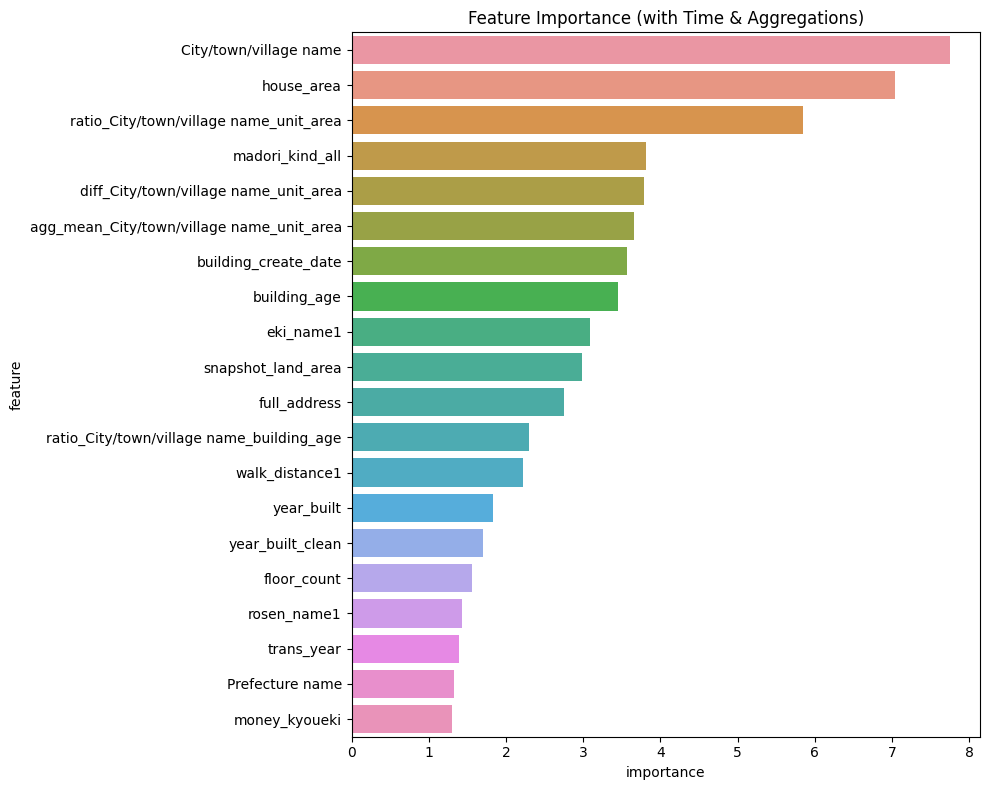

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from catboost import CatBoostRegressor, Pool
from sklearn.model_selection import GroupKFold
from sklearn.metrics import mean_absolute_percentage_error
import warnings
import gc

warnings.filterwarnings('ignore')

# 設定
OUTPUT_DIR = "/work/Real_estate"
TRAIN_PATH = f"{OUTPUT_DIR}/train/train_preprocessed_fixed.csv"
TEST_PATH = f"{OUTPUT_DIR}/test/test_preprocessed_fixed.csv"

def create_features(df):
    """
    既存カラムから新しい特徴量を生成する
    """
    df = df.copy()
    
    # 1. 時間・築年数関連 (Temporal Features)
    # target_ym (例: 201901) を 年と月に分解
    # これが「インフレ」を捉えるための最重要変数になります
    df['trans_year'] = df['target_ym'].astype(str).str[:4].astype(int)
    df['trans_month'] = df['target_ym'].astype(str).str[4:6].astype(int)
    
    # year_built のクリーニング（欠損や変な値を処理）
    def clean_year(x):
        try:
            val = int(x)
            if 1900 <= val <= 2030: return val
        except:
            pass
        return np.nan
    
    df['year_built_clean'] = df['year_built'].apply(clean_year)
    
    # ★築年数 (Building Age) - 最重要
    # 取引年 - 建築年 = 「取引時点での古さ」
    df['building_age'] = df['trans_year'] - df['year_built_clean']
    # 建築前（新築販売など）でマイナスになる場合は0にする
    df['building_age'] = df['building_age'].apply(lambda x: max(0, x) if pd.notnull(x) else np.nan)
    
    # 2. 面積・規模関連 (Size Interactions)
    # 部屋数で割った「1部屋あたりの平均建物面積」
    if 'total_floor_area' in df.columns and 'unit_count' in df.columns:
        df['area_per_unit'] = df['total_floor_area'] / df['unit_count']
    
    # 3. 地域ごとの統計量 (Aggregations)
    # 「このエリア(市区町村)の平均的な物件」と比較してどうか？
    group_col = 'City/town/village name'
    # ターゲットエンコーディング的なアプローチ（Xのみ使用）
    agg_cols = ['year_built_clean', 'unit_area', 'building_age'] 
    
    # 全体で計算
    for col in agg_cols:
        if col in df.columns:
            # 平均 (Mean)
            mean_map = df.groupby(group_col)[col].mean()
            df[f'agg_mean_{group_col}_{col}'] = df[group_col].map(mean_map)
            
            # 乖離 (Diff): エリア平均との差
            df[f'diff_{group_col}_{col}'] = df[col] - df[f'agg_mean_{group_col}_{col}']
            
            # 比率 (Ratio): エリア平均との比
            df[f'ratio_{group_col}_{col}'] = df[col] / df[f'agg_mean_{group_col}_{col}']

    return df

def train_and_evaluate_fe():
    print("1. Loading data...")
    train_df = pd.read_csv(TRAIN_PATH)
    test_df = pd.read_csv(TEST_PATH)
    
    # 特徴量作成のために一時結合
    train_df['is_train'] = 1
    test_df['is_train'] = 0
    test_df['money_room'] = np.nan
    
    combined = pd.concat([train_df, test_df], axis=0, ignore_index=True)
    
    print("2. Engineering Features (Adding Time & Aggregations)...")
    combined_fe = create_features(combined)
    
    # 再分割
    train_fe = combined_fe[combined_fe['is_train'] == 1].drop(columns=['is_train'])
    test_fe = combined_fe[combined_fe['is_train'] == 0].drop(columns=['is_train', 'money_room'])
    
    # 定義
    drop_cols = ['id', 'money_room', 'target_ym']
    target_col = 'money_room'
    group_col = 'City/town/village name'
    
    features = [c for c in train_fe.columns if c not in drop_cols + [target_col]]
    
    # カテゴリ変数の処理（CatBoost用）
    cat_cols = train_fe[features].select_dtypes(include=['object']).columns.tolist()
    print(f"Features: {len(features)}")
    
    X = train_fe[features]
    y = np.log1p(train_fe[target_col])
    groups = train_fe[group_col]
    
    X_test = test_fe[features]
    test_ids = test_df['id']
    
    # 文字列変換（CatBoostError回避）
    print("Converting categories...")
    for col in cat_cols:
        X[col] = X[col].astype(str).fillna("Missing")
        X_test[col] = X_test[col].astype(str).fillna("Missing")

    # 学習設定
    n_splits = 5
    kf = GroupKFold(n_splits=n_splits)
    
    oof_preds = np.zeros(len(X))
    test_preds = np.zeros(len(X_test))
    models = []
    scores = []
    
    params = {
        "loss_function": "MAE",
        "eval_metric": "MAE",
        "task_type": "GPU", # GPU環境ならコメントアウトを外す
        "learning_rate": 0.05,
        "iterations": 5000,
        "depth": 7, 
        "random_seed": 2025,
        "verbose": 1000,
        "early_stopping_rounds": 200
    }
    
    print(f"3. Starting Training with New Features...")
    
    for fold, (train_idx, val_idx) in enumerate(kf.split(X, y, groups=groups)):
        X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
        X_val, y_val = X.iloc[val_idx], y.iloc[val_idx]
        
        train_pool = Pool(X_train, y_train, cat_features=cat_cols)
        val_pool = Pool(X_val, y_val, cat_features=cat_cols)
        
        model = CatBoostRegressor(**params)
        model.fit(train_pool, eval_set=val_pool, use_best_model=True)
        
        pred_val = np.expm1(model.predict(X_val))
        score = mean_absolute_percentage_error(np.expm1(y_val), pred_val)
        scores.append(score)
        oof_preds[val_idx] = pred_val
        test_preds += np.expm1(model.predict(X_test)) / n_splits
        
        models.append(model)
        print(f"Fold {fold+1} MAPE: {score:.4f}")
        
    mean_score = np.mean(scores)
    print(f"\n==================================")
    print(f"Previous CV : 0.2488")
    print(f"New CV Score: {mean_score:.4f}")
    print(f"==================================\n")
    
    # 提出用ファイル作成
    sub = pd.DataFrame({"id": test_ids, "money_room": test_preds})
    sub.to_csv("submission_fe_1.csv", index=False, header=False)
    
    # 重要度可視化
    fi_df = pd.DataFrame({
        'feature': features,
        'importance': np.mean([m.get_feature_importance() for m in models], axis=0)
    }).sort_values('importance', ascending=False).head(20)
    
    plt.figure(figsize=(10, 8))
    sns.barplot(x='importance', y='feature', data=fi_df)
    plt.title('Feature Importance (with Time & Aggregations)')
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    train_and_evaluate_fe()

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from catboost import CatBoostRegressor, Pool
from sklearn.model_selection import GroupKFold
from sklearn.metrics import mean_absolute_percentage_error
import warnings

warnings.filterwarnings('ignore')

# 設定
OUTPUT_DIR = "/work/Real_estate"
TRAIN_PATH = f"{OUTPUT_DIR}/train/train_preprocessed_fixed.csv"
TEST_PATH = f"{OUTPUT_DIR}/test/test_preprocessed_fixed.csv"

# --- 1. 都市グルーピング特徴量 ---
class CityFeatureEngineer:
    def __init__(self):
        # 4大都市圏・政令指定都市などを定義
        self.major_cities = [
            '千代田区', '中央区', '港区', '新宿区', '文京区', '渋谷区', # 東京都心
            '大阪市', '名古屋市', '横浜市', '福岡市', '川崎市'
        ]
        # 新興・中核都市
        self.emerging_cities = [
            '札幌市', '仙台市', '広島市', '神戸市', '京都市', 'さいたま市', '千葉市', 
            '堺市', '新潟市', '浜松市', '熊本市', '相模原市', '岡山市', '静岡市'
        ]

    def transform(self, df):
        df = df.copy()
        city_col = 'City/town/village name'
        
        def classify_city(city_name):
            c_str = str(city_name)
            for c in self.major_cities:
                if c in c_str: return 'Major'
            for c in self.emerging_cities:
                if c in c_str: return 'Emerging'
            return 'Others'
        
        df['city_tier'] = df[city_col].apply(classify_city)
        return df

# --- 2. 建物種別グルーピング ---
def get_building_group(b_type):
    # ユーザー提供の定義に基づくグルーピング
    # 1:マンション, 3:アパート, 8:ビル, 12:寮, 13:ホテル, 14:旅館
    if b_type in [1, 3, 8, 12, 13, 14]:
        return 'Mansion_Apt'
    # 2:タウンハウス, 4:一戸建, 5:テラスハウス
    elif b_type in [2, 4, 5]:
        return 'House_Terrace'
    # 6:土地, 7:駐車場, 9:店舗, 10:倉庫, 11:工場, 15:その他
    else:
        return 'Others'

# --- 3. 前処理と特徴量作成 ---
def preprocess_data(train_path, test_path):
    print("Loading data...")
    train_df = pd.read_csv(train_path)
    test_df = pd.read_csv(test_path)
    
    # 目的変数退避
    train_y = train_df['money_room']
    train_df = train_df.drop(columns=['money_room'])
    
    # 結合して処理
    train_df['is_train'] = 1
    test_df['is_train'] = 0
    combined = pd.concat([train_df, test_df], axis=0, ignore_index=True)
    
    # A. 都市Tier追加
    city_eng = CityFeatureEngineer()
    combined = city_eng.transform(combined)
    
    # B. 建物グループ追加
    # building_type が数値であることを想定
    combined['building_group'] = combined['building_type'].apply(get_building_group)
    
    # C. 時系列特徴量 (Inflation)
    combined['trans_year'] = combined['target_ym'].astype(str).str[:4].astype(int)
    
    # D. カテゴリ変数の欠損埋め
    cat_cols = combined.select_dtypes(include=['object']).columns.tolist()
    for col in cat_cols:
        combined[col] = combined[col].astype(str).fillna("Missing")
        
    # 再分割
    train_processed = combined[combined['is_train'] == 1].drop(columns=['is_train'])
    test_processed = combined[combined['is_train'] == 0].drop(columns=['is_train'])
    
    train_processed['money_room'] = train_y.values
    
    return train_processed, test_processed

# --- 4. 分割学習実行クラス ---
class SplitModelTrainer:
    def run(self):
        train_df, test_df = preprocess_data(TRAIN_PATH, TEST_PATH)
        
        target_col = 'money_room'
        split_col = 'building_group'
        
        unique_groups = train_df[split_col].unique()
        print(f"Splitting data into groups: {unique_groups}")
        
        final_test_preds = pd.Series(index=test_df.index, dtype=float)
        oof_preds = pd.Series(index=train_df.index, dtype=float)
        
        # 特徴量リスト (IDや目的変数、分割キー自体は除外しても良いが、念のため残すことも可能)
        drop_cols = ['id', 'money_room', 'target_ym', 'is_train'] 
        # building_groupは特徴量としても使えるが、モデルが分かれているので冗長。削除してもOK。
        
        features = [c for c in train_df.columns if c not in drop_cols]
        cat_cols = train_df[features].select_dtypes(include=['object']).columns.tolist()
        
        print(f"Features count: {len(features)}")

        for group in unique_groups:
            print(f"\n>>> Training Model for Group: {group} <<<")
            
            # データの抽出
            X_type = train_df[train_df[split_col] == group]
            y_type = np.log1p(X_type[target_col])
            
            test_indices = test_df[test_df[split_col] == group].index
            X_test_type = test_df.loc[test_indices, features]
            
            if len(X_type) < 100:
                print(f"Skipping {group} (Not enough data)")
                continue
                
            # GroupKFold (City単位)
            groups = X_type['City/town/village name']
            kf = GroupKFold(n_splits=5)
            
            type_preds = np.zeros(len(X_test_type))
            type_oof = np.zeros(len(X_type))
            scores = []
            
            # グループごとにパラメータを微調整することも可能だが、まずは共通で
            params = {
                "loss_function": "MAE",
                "eval_metric": "MAE",
                "learning_rate": 0.05,
                "iterations": 5000,
                "depth": 7,
                "random_seed": 2025,
                "verbose": 500,
                "early_stopping_rounds": 200
            }

            for fold, (train_idx, val_idx) in enumerate(kf.split(X_type, y_type, groups=groups)):
                X_tr, y_tr = X_type.iloc[train_idx][features], y_type.iloc[train_idx]
                X_val, y_val = X_type.iloc[val_idx][features], y_type.iloc[val_idx]
                
                train_pool = Pool(X_tr, y_tr, cat_features=cat_cols)
                val_pool = Pool(X_val, y_val, cat_features=cat_cols)
                
                model = CatBoostRegressor(**params)
                model.fit(train_pool, eval_set=val_pool, use_best_model=True)
                
                pred_val = np.expm1(model.predict(X_val))
                type_oof[val_idx] = pred_val
                
                if len(X_test_type) > 0:
                    type_preds += np.expm1(model.predict(X_test_type)) / 5
                
                score = mean_absolute_percentage_error(np.expm1(y_val), pred_val)
                scores.append(score)
            
            mean_score = np.mean(scores)
            print(f"Group {group} - Average MAPE: {mean_score:.4f}")
            
            oof_preds.loc[X_type.index] = type_oof
            if len(X_test_type) > 0:
                final_test_preds.loc[test_indices] = type_preds

        # 全体スコア
        valid_idx = oof_preds.dropna().index
        total_score = mean_absolute_percentage_error(train_df.loc[valid_idx, target_col], oof_preds.loc[valid_idx])
        
        print(f"\n==================================")
        print(f"Overall CV Score (Split Model): {total_score:.4f}")
        print(f"==================================\n")
        
        # 提出ファイル
        sub = pd.DataFrame({"id": test_df['id'], "money_room": final_test_preds})
        sub['money_room'] = sub['money_room'].fillna(sub['money_room'].mean())
        sub.to_csv("submission_split_model.csv", index=False, header=False)
        print("Saved submission_split_model.csv")

if __name__ == "__main__":
    trainer = SplitModelTrainer()
    trainer.run()

Loading data...
Splitting data into groups: ['House_Terrace' 'Mansion_Apt' 'Others']
Features count: 511

>>> Training Model for Group: House_Terrace <<<
0:	learn: 0.4762164	test: 0.5045663	best: 0.5045663 (0)	total: 535ms	remaining: 44m 36s
500:	learn: 0.1870006	test: 0.2833046	best: 0.2833046 (500)	total: 2m 34s	remaining: 23m 4s
1000:	learn: 0.1714159	test: 0.2613078	best: 0.2613078 (1000)	total: 5m 11s	remaining: 20m 45s
1500:	learn: 0.1619854	test: 0.2538437	best: 0.2538437 (1500)	total: 7m 52s	remaining: 18m 20s
2000:	learn: 0.1554519	test: 0.2503718	best: 0.2503677 (1999)	total: 10m 36s	remaining: 15m 53s
2500:	learn: 0.1503304	test: 0.2484840	best: 0.2483309 (2466)	total: 13m 23s	remaining: 13m 22s
3000:	learn: 0.1459202	test: 0.2469863	best: 0.2469863 (3000)	total: 16m 8s	remaining: 10m 44s
3500:	learn: 0.1423312	test: 0.2458093	best: 0.2458093 (3500)	total: 18m 51s	remaining: 8m 4s
4000:	learn: 0.1393192	test: 0.2451480	best: 0.2451374 (3978)	total: 21m 37s	remaining: 5m 23s


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from catboost import CatBoostRegressor, Pool
from sklearn.model_selection import GroupKFold
from sklearn.metrics import mean_absolute_percentage_error
import warnings
import os
import geopandas as gpd
from scipy.spatial import cKDTree

warnings.filterwarnings('ignore')

# 設定
GIS_DIR = "/work/Real_estate/gis_data" # GISデータがあればここを指定

OUTPUT_DIR = "/work/Real_estate"
TRAIN_PATH = f"{OUTPUT_DIR}/train/train_preprocessed_fixed.csv"
TEST_PATH = f"{OUTPUT_DIR}/test/test_preprocessed_fixed.csv"
# ==========================================
# 1. 特徴量エンジニアリング工場 (Feature Factory)
# ==========================================
class FeatureFactory:
    def __init__(self, use_gis=False):
        self.use_gis = use_gis
        self.land_price_df = None
        
        # 都市定義
        self.major_cities = ['千代田区', '中央区', '港区', '新宿区', '文京区', '渋谷区', '大阪市', '名古屋市', '横浜市', '福岡市', '川崎市']
        self.emerging_cities = ['札幌市', '仙台市', '広島市', '神戸市', '京都市', 'さいたま市', '千葉市', '堺市', '新潟市', '浜松市', '熊本市', '相模原市', '岡山市', '静岡市']

    def _clean_year(self, x):
        try:
            val = int(x)
            if 1900 <= val <= 2030: return val
        except:
            pass
        return np.nan

    def _classify_city(self, city_name):
        c_str = str(city_name)
        for c in self.major_cities:
            if c in c_str: return 'Major'
        for c in self.emerging_cities:
            if c in c_str: return 'Emerging'
        return 'Others'
    
    def _get_building_group(self, b_type):
        # 1:マンション, 3:アパート, 8:ビル, 12:寮, 13:ホテル, 14:旅館
        if b_type in [1, 3, 8, 12, 13, 14]: return 'Mansion_Apt'
        # 2:タウンハウス, 4:一戸建, 5:テラスハウス
        elif b_type in [2, 4, 5]: return 'House_Terrace'
        # その他
        else: return 'Others'

    def _load_gis(self):
        if not self.use_gis or not os.path.exists(GIS_DIR):
            return
        print("Loading GIS Data...")
        gdf_list = []
        for root, dirs, files in os.walk(GIS_DIR):
            for file in files:
                if file.endswith(".shp") and "L01" in file:
                    try:
                        gdf = gpd.read_file(os.path.join(root, file))
                        col = 'L01_006' if 'L01_006' in gdf.columns else 'L01_0006'
                        if col in gdf.columns:
                            gdf_list.append(pd.DataFrame({'price': pd.to_numeric(gdf[col], errors='coerce'), 'geo': gdf.geometry}))
                    except: pass
        if gdf_list:
            self.land_price_df = pd.concat(gdf_list, ignore_index=True)
            self.land_price_df['lon'] = self.land_price_df.geo.x
            self.land_price_df['lat'] = self.land_price_df.geo.y
            self.land_price_df = self.land_price_df[self.land_price_df['price'] > 0]
            self.gis_tree = cKDTree(self.land_price_df[['lon', 'lat']].values)

    def _attach_gis(self, df):
        if self.land_price_df is None: return df
        print("Attaching GIS Land Price...")
        if 'lon' in df.columns and 'lat' in df.columns:
            dists, idxs = self.gis_tree.query(df[['lon', 'lat']].values, k=1)
            df['nearest_land_price'] = self.land_price_df.iloc[idxs]['price'].values
            df['dist_to_price'] = dists
            df['log_land_price'] = np.log1p(df['nearest_land_price'])
        return df

    def transform(self, df):
        print("Creating Features...")
        df = df.copy()
        
        # A. 基本加工
        df['trans_year'] = df['target_ym'].astype(str).str[:4].astype(int)
        df['year_built_clean'] = df['year_built'].apply(self._clean_year)
        df['building_age'] = df['trans_year'] - df['year_built_clean']
        df['building_age'] = df['building_age'].apply(lambda x: max(0, x) if pd.notnull(x) else np.nan)
        if 'total_floor_area' in df.columns and 'unit_count' in df.columns:
            df['area_per_unit'] = df['total_floor_area'] / df['unit_count']

        # B. グルーピング
        df['city_tier'] = df['City/town/village name'].apply(self._classify_city)
        df['building_group'] = df['building_type'].apply(self._get_building_group)

        # C. 地域統計 (Aggregations) - これがCV向上の肝
        # 「その市区町村の平均」との乖離
        group_col = 'City/town/village name'
        agg_targets = ['year_built_clean', 'unit_area', 'building_age', 'nearest_land_price']
        
        # GISデータがあればそれも集計対象に
        if self.use_gis: self._load_gis(); df = self._attach_gis(df)
        
        print("Calculating Aggregations...")
        for col in agg_targets:
            if col in df.columns:
                # 全体平均での埋め合わせ（欠損対策）
                df[col] = df[col].fillna(df[col].mean())
                # Groupごとの平均
                grp_mean = df.groupby(group_col)[col].transform('mean')
                df[f'diff_{col}_city'] = df[col] - grp_mean
                df[f'ratio_{col}_city'] = df[col] / grp_mean

        return df

# ==========================================
# 2. 学習・推論クラス (Split Trainer)
# ==========================================
class AdvancedSplitTrainer:
    def __init__(self, train_path, test_path):
        self.train_path = train_path
        self.test_path = test_path

    def run(self):
        # データ読み込み
        train_df = pd.read_csv(self.train_path)
        test_df = pd.read_csv(self.test_path)
        
        train_y = train_df['money_room']
        train_df = train_df.drop(columns=['money_room'])
        
        train_df['is_train'] = 1
        test_df['is_train'] = 0
        combined = pd.concat([train_df, test_df], axis=0, ignore_index=True)
        
        # 特徴量生成 (GISを使う場合は use_gis=True に変更してください)
        # ※ 地価データ(.shp)を配置済みなら True に変更推奨！
        factory = FeatureFactory(use_gis=False) 
        combined = factory.transform(combined)
        
        # カテゴリ処理
        cat_cols = combined.select_dtypes(include=['object']).columns.tolist()
        for col in cat_cols:
            combined[col] = combined[col].astype(str).fillna("Missing")

        # データ分割
        train_proc = combined[combined['is_train'] == 1]
        test_proc = combined[combined['is_train'] == 0]
        train_proc['money_room'] = train_y.values

        # 学習ループ
        split_col = 'building_group'
        groups = train_proc[split_col].unique()
        
        oof_preds = pd.Series(index=train_proc.index, dtype=float)
        final_preds = pd.Series(index=test_proc.index, dtype=float)
        
        drop_cols = ['id', 'money_room', 'target_ym', 'is_train', 'geometry']
        features = [c for c in train_proc.columns if c not in drop_cols]
        
        print(f"\nTraining with {len(features)} features on groups: {groups}")

        for grp in groups:
            print(f"\n>>> Group: {grp} <<<")
            
            # データ抽出
            tr_idx = train_proc[train_proc[split_col] == grp].index
            te_idx = test_proc[test_proc[split_col] == grp].index
            
            X_grp = train_proc.loc[tr_idx, features]
            y_grp = np.log1p(train_proc.loc[tr_idx, 'money_room'])
            X_test_grp = test_proc.loc[te_idx, features]
            
            # GroupKFold (City単位)
            city_groups = train_proc.loc[tr_idx, 'City/town/village name']
            kf = GroupKFold(n_splits=5)
            
            grp_oof = np.zeros(len(X_grp))
            grp_test_preds = np.zeros(len(X_test_grp))
            scores = []
            
            params = {
                "loss_function": "MAE",
                "eval_metric": "MAE",
                "task_type": "GPU", # GPU環境ならコメントアウトを外す
                "learning_rate": 0.05,
                "iterations": 6000, # 少し増やす
                "depth": 7,
                "random_seed": 2025,
                "verbose": 1000,
                "early_stopping_rounds": 300
            }
            
            for fold, (train_idx, val_idx) in enumerate(kf.split(X_grp, y_grp, groups=city_groups)):
                X_t, y_t = X_grp.iloc[train_idx], y_grp.iloc[train_idx]
                X_v, y_v = X_grp.iloc[val_idx], y_grp.iloc[val_idx]
                
                # Pool作成
                train_pool = Pool(X_t, y_t, cat_features=cat_cols)
                val_pool = Pool(X_v, y_v, cat_features=cat_cols)
                
                model = CatBoostRegressor(**params)
                model.fit(train_pool, eval_set=val_pool, use_best_model=True)
                
                pred_v = np.expm1(model.predict(X_v))
                grp_oof[val_idx] = pred_v
                scores.append(mean_absolute_percentage_error(np.expm1(y_v), pred_v))
                
                if len(X_test_grp) > 0:
                    grp_test_preds += np.expm1(model.predict(X_test_grp)) / 5
            
            print(f"Group {grp} MAPE: {np.mean(scores):.4f}")
            
            oof_preds.loc[tr_idx] = grp_oof
            if len(X_test_grp) > 0:
                final_preds.loc[te_idx] = grp_test_preds

        # 全体スコア
        total_score = mean_absolute_percentage_error(train_y, oof_preds)
        print(f"\n==================================")
        print(f"Total CV Score: {total_score:.4f}")
        print(f"==================================\n")
        
        # 保存
        sub = pd.DataFrame({"id": test_proc['id'], "money_room": final_preds})
        sub['money_room'] = sub['money_room'].fillna(sub['money_room'].mean())
        sub.to_csv("submission_unified.csv", index=False, header=False)
        print("Saved submission_unified.csv")

if __name__ == "__main__":
    trainer = AdvancedSplitTrainer(TRAIN_PATH, TEST_PATH)
    trainer.run()

Creating Features...
Calculating Aggregations...

Training with 520 features on groups: ['House_Terrace' 'Mansion_Apt' 'Others']

>>> Group: House_Terrace <<<


Default metric period is 5 because MAE is/are not implemented for GPU


0:	learn: 0.4786376	test: 0.5041499	best: 0.5041499 (0)	total: 184ms	remaining: 18m 26s
1000:	learn: 0.1597648	test: 0.2528324	best: 0.2528324 (1000)	total: 1m 30s	remaining: 7m 31s
2000:	learn: 0.1374294	test: 0.2472917	best: 0.2472845 (1988)	total: 3m 1s	remaining: 6m 3s
3000:	learn: 0.1222094	test: 0.2450776	best: 0.2450199 (2956)	total: 4m 28s	remaining: 4m 28s
4000:	learn: 0.1113349	test: 0.2443389	best: 0.2441927 (3884)	total: 5m 55s	remaining: 2m 57s
bestTest = 0.2436179977
bestIteration = 4681
Shrink model to first 4682 iterations.


Default metric period is 5 because MAE is/are not implemented for GPU


0:	learn: 0.4788822	test: 0.5028954	best: 0.5028954 (0)	total: 145ms	remaining: 14m 31s
1000:	learn: 0.1601565	test: 0.2457423	best: 0.2457400 (997)	total: 1m 26s	remaining: 7m 14s
2000:	learn: 0.1376448	test: 0.2400221	best: 0.2399155 (1974)	total: 2m 52s	remaining: 5m 44s
3000:	learn: 0.1228395	test: 0.2388651	best: 0.2387693 (2906)	total: 4m 23s	remaining: 4m 23s
4000:	learn: 0.1120811	test: 0.2381612	best: 0.2380641 (3978)	total: 5m 54s	remaining: 2m 57s
bestTest = 0.2380641233
bestIteration = 3978
Shrink model to first 3979 iterations.


...

0:	learn: 0.5218351	test: 0.5503696	best: 0.5503696 (0)	total: 103ms	remaining: 10m 15s
1000:	learn: 0.1637858	test: 0.2910757	best: 0.2910370 (995)	total: 1m 28s	remaining: 7m 24s
bestTest = 0.2862122194
bestIteration = 1555
Shrink model to first 1556 iterations.


Default metric period is 5 because MAE is/are not implemented for GPU


0:	learn: 0.5298499	test: 0.5166204	best: 0.5166204 (0)	total: 97.4ms	remaining: 9m 44s
1000:	learn: 0.1609137	test: 0.2857348	best: 0.2855600 (970)	total: 1m 28s	remaining: 7m 23s
2000:	learn: 0.1221185	test: 0.2813753	best: 0.2806928 (1852)	total: 2m 58s	remaining: 5m 57s
bestTest = 0.279480797
bestIteration = 2117
Shrink model to first 2118 iterations.


Default metric period is 5 because MAE is/are not implemented for GPU


0:	learn: 0.5293004	test: 0.5218654	best: 0.5218654 (0)	total: 108ms	remaining: 10m 47s
1000:	learn: 0.1666219	test: 0.2701973	best: 0.2696252 (892)	total: 1m 32s	remaining: 7m 39s
2000:	learn: 0.1262220	test: 0.2655964	best: 0.2654295 (1870)	total: 3m 3s	remaining: 6m 6s
bestTest = 0.264764974
bestIteration = 2115
Shrink model to first 2116 iterations.
Group Others MAPE: 0.2840

Total CV Score: 0.2256

Saved submission_unified.csv


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from catboost import CatBoostRegressor, Pool
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.linear_model import LinearRegression
import warnings
import os
import geopandas as gpd
from scipy.spatial import cKDTree

warnings.filterwarnings('ignore')

# 設定
# GISデータがあればTrue, なければFalse
USE_GIS = True
GIS_DIR = "/work/Real_estate/gis_data" 
OUTPUT_DIR = "/work/Real_estate"
TRAIN_PATH = f"{OUTPUT_DIR}/train/train_preprocessed_fixed.csv"
TEST_PATH = f"{OUTPUT_DIR}/test/test_preprocessed_fixed.csv"

# ==========================================
# 1. 特徴量エンジニアリング (共通)
# ==========================================
class FeatureFactory:
    def __init__(self, use_gis=False):
        self.use_gis = use_gis
        self.land_price_df = None
        self.major_cities = ['千代田区', '中央区', '港区', '新宿区', '文京区', '渋谷区', '大阪市', '名古屋市', '横浜市', '福岡市', '川崎市']
        self.emerging_cities = ['札幌市', '仙台市', '広島市', '神戸市', '京都市', 'さいたま市', '千葉市', '堺市', '新潟市', '浜松市', '熊本市', '相模原市', '岡山市', '静岡市']

    def _clean_year(self, x):
        try:
            val = int(x)
            if 1900 <= val <= 2030: return val
        except: pass
        return np.nan

    def _classify_city(self, city_name):
        c_str = str(city_name)
        for c in self.major_cities:
            if c in c_str: return 'Major'
        for c in self.emerging_cities:
            if c in c_str: return 'Emerging'
        return 'Others'
    
    def _get_building_group(self, b_type):
        if b_type in [1, 3, 8, 12, 13, 14]: return 'Mansion_Apt'
        elif b_type in [2, 4, 5]: return 'House_Terrace'
        else: return 'Others'

    def _load_gis(self):
        if not self.use_gis or not os.path.exists(GIS_DIR): return
        print("Loading GIS Data...")
        gdf_list = []
        for root, dirs, files in os.walk(GIS_DIR):
            for file in files:
                if file.endswith(".shp") and "L01" in file:
                    try:
                        gdf = gpd.read_file(os.path.join(root, file))
                        col = 'L01_008' if 'L01_008' in gdf.columns else 'L01_0008'
                        if col in gdf.columns:
                            gdf_list.append(pd.DataFrame({'price': pd.to_numeric(gdf[col], errors='coerce'), 'geo': gdf.geometry}))
                    except: pass
        if gdf_list:
            self.land_price_df = pd.concat(gdf_list, ignore_index=True)
            self.land_price_df['lon'] = self.land_price_df.geo.x
            self.land_price_df['lat'] = self.land_price_df.geo.y
            self.land_price_df = self.land_price_df[self.land_price_df['price'] > 0]
            self.gis_tree = cKDTree(self.land_price_df[['lon', 'lat']].values)

    def _attach_gis(self, df):
        if self.land_price_df is None: return df
        if 'lon' in df.columns and 'lat' in df.columns:
            dists, idxs = self.gis_tree.query(df[['lon', 'lat']].values, k=1)
            df['nearest_land_price'] = self.land_price_df.iloc[idxs]['price'].values
            df['dist_to_price'] = dists
        return df

    def transform(self, df):
        print("Creating Features...")
        df = df.copy()
        
        df['trans_year'] = df['target_ym'].astype(str).str[:4].astype(int)
        df['year_built_clean'] = df['year_built'].apply(self._clean_year)
        df['building_age'] = df['trans_year'] - df['year_built_clean']
        df['building_age'] = df['building_age'].apply(lambda x: max(0, x) if pd.notnull(x) else np.nan)
        if 'total_floor_area' in df.columns and 'unit_count' in df.columns:
            df['area_per_unit'] = df['total_floor_area'] / df['unit_count']

        df['city_tier'] = df['City/town/village name'].apply(self._classify_city)
        df['building_group'] = df['building_type'].apply(self._get_building_group)

        # 地域統計
        group_col = 'City/town/village name'
        agg_targets = ['year_built_clean', 'unit_area', 'building_age']
        if self.use_gis: self._load_gis(); df = self._attach_gis(df); agg_targets.append('nearest_land_price')
        
        for col in agg_targets:
            if col in df.columns:
                df[col] = df[col].fillna(df[col].mean())
                grp_mean = df.groupby(group_col)[col].transform('mean')
                df[f'diff_{col}_city'] = df[col] - grp_mean
                df[f'ratio_{col}_city'] = df[col] / grp_mean
        return df

# ==========================================
# 2. トレンド除去 & 学習クラス (De-trending Trainer)
# ==========================================
class DetrendingTrainer:
    def __init__(self, train_path, test_path):
        self.train_path = train_path
        self.test_path = test_path
        self.trend_model = None
        self.year_means = {}

    def fit_trend(self, df):
        """
        年ごとの平均価格を計算し、2023年を予測する線形モデルを作成
        """
        print("\n--- Fitting Price Trend ---")
        # 外れ値を除去した平均（中央値に近いロバストな平均）を使う
        yearly_stats = df.groupby('trans_year')['money_room'].apply(lambda x: np.mean(np.log1p(x)))
        X_year = np.array(yearly_stats.index).reshape(-1, 1)
        y_mean = yearly_stats.values
        
        self.trend_model = LinearRegression()
        self.trend_model.fit(X_year, y_mean)
        
        # 予測
        years = np.append(X_year.flatten(), [2023])
        preds = self.trend_model.predict(years.reshape(-1, 1))
        
        # 辞書に保存
        self.year_means = dict(zip(years, preds))
        
        print("Yearly Log-Price Trend:")
        for y, p in self.year_means.items():
            print(f"  {y}: {p:.4f} (exp: {np.expm1(p):.0f})")
        
        # 傾き（インフレ率）
        slope = self.trend_model.coef_[0]
        print(f"  Annual Growth Rate (approx): {slope*100:.2f}%")

    def run(self):
        # データの準備
        train_df = pd.read_csv(self.train_path)
        test_df = pd.read_csv(self.test_path)
        
        train_y = train_df['money_room']
        train_df = train_df.drop(columns=['money_room'])
        train_df['is_train'] = 1
        test_df['is_train'] = 0
        combined = pd.concat([train_df, test_df], axis=0, ignore_index=True)
        
        factory = FeatureFactory(use_gis=USE_GIS)
        combined = factory.transform(combined)
        
        # カテゴリ処理
        cat_cols = combined.select_dtypes(include=['object']).columns.tolist()
        for col in cat_cols:
            combined[col] = combined[col].astype(str).fillna("Missing")

        # 再分割
        train_proc = combined[combined['is_train'] == 1]
        test_proc = combined[combined['is_train'] == 0]
        train_proc['money_room'] = train_y.values
        
        # 1. トレンドモデルの学習
        self.fit_trend(train_proc)
        
        # 2. ターゲットの変換 (De-trending)
        # log(y) - log(year_mean) を予測対象にする（＝その年の平均からの乖離）
        # これにより、モデルは「インフレ」を無視して「物件の価値」だけを学習する
        train_proc['log_price'] = np.log1p(train_proc['money_room'])
        # 各行の取引年に対応する平均値を引く
        train_year_means = train_proc['trans_year'].map(self.year_means)
        train_proc['relative_price'] = train_proc['log_price'] - train_year_means
        
        y_target = train_proc['relative_price'] # これが新しい目的変数

        # 3. 時系列分割バリデーション (Time Series Split)
        # 2022年をValid、それ以前をTrainにする（未来予測のシミュレーション）
        print("\n--- Time Series Validation (Train < 2022, Valid >= 2022) ---")
        
        train_mask = train_proc['trans_year'] < 2022
        val_mask = train_proc['trans_year'] >= 2022
        
        X_train = train_proc[train_mask]
        y_train = y_target[train_mask]
        X_val = train_proc[val_mask]
        y_val = y_target[val_mask]
        
        # 特徴量
        drop_cols = ['id', 'money_room', 'log_price', 'relative_price', 'target_ym', 'is_train', 'geometry']
        features = [c for c in train_proc.columns if c not in drop_cols]
        
        print(f"Train size: {len(X_train)}, Valid size: {len(X_val)}")
        
        # 学習
        train_pool = Pool(X_train[features], y_train, cat_features=cat_cols)
        val_pool = Pool(X_val[features], y_val, cat_features=cat_cols)
        
        params = {
            "loss_function": "MAE", # 相対価格のMAEを最小化
            "eval_metric": "MAE",
            "learning_rate": 0.05,
            "task_type": "GPU", # GPU環境ならコメントアウトを外す
            "iterations": 5000,
            "depth": 6, # 過学習抑制のため少し浅く
            "l2_leaf_reg": 5, # 正則化を強める
            "random_seed": 2025,
            "verbose": 500,
            "early_stopping_rounds": 200
        }
        
        model = CatBoostRegressor(**params)
        model.fit(train_pool, eval_set=val_pool, use_best_model=True)
        
        # 4. バリデーションスコア確認（トレンドを戻して計算）
        # 予測値(相対) + その年の平均(トレンド)
        pred_relative = model.predict(X_val[features])
        val_trend = X_val['trans_year'].map(self.year_means)
        pred_log = pred_relative + val_trend
        pred_final = np.expm1(pred_log)
        
        y_true = train_proc.loc[val_mask, 'money_room']
        score = mean_absolute_percentage_error(y_true, pred_final)
        
        print(f"\n==================================")
        print(f"Time Split CV Score: {score:.4f}")
        print(f"==================================\n")
        
        # 5. 全データで再学習 & 本番予測
        print("--- Retraining on Full Data & Predicting 2023 ---")
        full_pool = Pool(train_proc[features], y_target, cat_features=cat_cols)
        model_full = CatBoostRegressor(**params)
        model_full.fit(full_pool, verbose=500)
        
        # テストデータの予測
        # 2023年のトレンド（予測値）を足す
        test_pred_relative = model_full.predict(test_proc[features])
        # テストデータはすべて2023年と仮定（またはtarget_ymから取得）
        test_trend = test_proc['trans_year'].map(self.year_means).fillna(self.year_means[2023]) # 2023の予測平均
        
        test_pred_log = test_pred_relative + test_trend
        test_pred_final = np.expm1(test_pred_log)
        
        # 保存
        sub = pd.DataFrame({"id": test_proc['id'], "money_room": test_pred_final})
        sub.to_csv("submission_detrend.csv", index=False, header=False)
        print("Saved submission_detrend.csv")

if __name__ == "__main__":
    trainer = DetrendingTrainer(TRAIN_PATH, TEST_PATH)
    trainer.run()

Creating Features...

--- Fitting Price Trend ---
Yearly Log-Price Trend:
  2019: 16.8312 (exp: 20402491)
  2020: 16.8590 (exp: 20977931)
  2021: 16.8868 (exp: 21569601)
  2022: 16.9146 (exp: 22177958)
  2023: 16.9424 (exp: 22803474)
  Annual Growth Rate (approx): 2.78%

--- Time Series Validation (Train < 2022, Valid >= 2022) ---
Train size: 274358, Valid size: 89566


Default metric period is 5 because MAE is/are not implemented for GPU


0:	learn: 0.4808703	test: 0.4979642	best: 0.4979642 (0)	total: 245ms	remaining: 20m 23s
500:	learn: 0.1714366	test: 0.1919354	best: 0.1919354 (500)	total: 47.4s	remaining: 7m 5s
1000:	learn: 0.1572449	test: 0.1853858	best: 0.1853623 (995)	total: 1m 33s	remaining: 6m 14s
bestTest = 0.1842047912
bestIteration = 1099
Shrink model to first 1100 iterations.

Time Split CV Score: 0.1782

--- Retraining on Full Data & Predicting 2023 ---


Default metric period is 5 because MAE is/are not implemented for GPU


0:	learn: 0.4850078	total: 267ms	remaining: 22m 12s
500:	learn: 0.1718361	total: 50.3s	remaining: 7m 31s
1000:	learn: 0.1580788	total: 1m 40s	remaining: 6m 40s
1500:	learn: 0.1506839	total: 2m 29s	remaining: 5m 47s
2000:	learn: 0.1455724	total: 3m 16s	remaining: 4m 55s
2500:	learn: 0.1415461	total: 4m 5s	remaining: 4m 4s
3000:	learn: 0.1382767	total: 4m 54s	remaining: 3m 16s
3500:	learn: 0.1353033	total: 5m 43s	remaining: 2m 26s
4000:	learn: 0.1327196	total: 6m 30s	remaining: 1m 37s
4500:	learn: 0.1303364	total: 7m 17s	remaining: 48.5s
4999:	learn: 0.1282045	total: 8m 4s	remaining: 0us
Saved submission_detrend_add_gis.csv


In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from catboost import CatBoostRegressor, Pool
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.linear_model import LinearRegression
import warnings
import os
import re # 正規表現用

warnings.filterwarnings('ignore')

# 設定
USE_GIS = False 
GIS_DIR = "/work/Real_estate/gis_data" 
OUTPUT_DIR = "/work/Real_estate"
TRAIN_PATH = f"{OUTPUT_DIR}/train/train_preprocessed_fixed.csv"
TEST_PATH = f"{OUTPUT_DIR}/test/test_preprocessed_fixed.csv"

# ==========================================
# 1. 特徴量エンジニアリング (拡張版)
# ==========================================
class FeatureFactory:
    def __init__(self, use_gis=False):
        self.use_gis = use_gis
        self.major_cities = ['千代田区', '中央区', '港区', '新宿区', '文京区', '渋谷区', '大阪市', '名古屋市', '横浜市', '福岡市', '川崎市']
        self.emerging_cities = ['札幌市', '仙台市', '広島市', '神戸市', '京都市', 'さいたま市', '千葉市', '堺市', '新潟市', '浜松市', '熊本市', '相模原市', '岡山市', '静岡市']

    def _clean_year(self, x):
        try:
            val = int(x)
            if 1900 <= val <= 2030: return val
        except: pass
        return np.nan

    def _classify_city(self, city_name):
        c_str = str(city_name)
        for c in self.major_cities:
            if c in c_str: return 'Major'
        for c in self.emerging_cities:
            if c in c_str: return 'Emerging'
        return 'Others'
    
    def _get_building_group(self, b_type):
        if b_type in [1, 3, 8, 12, 13, 14]: return 'Mansion_Apt'
        elif b_type in [2, 4, 5]: return 'House_Terrace'
        else: return 'Others'
    
    # ★追加: 徒歩分数の抽出
    def _extract_station_time(self, x):
        # "徒歩5分", "徒歩 10分" などのパターンから数値を抽出
        if pd.isna(x): return np.nan
        match = re.search(r'徒歩\s*(\d+)', str(x))
        if match:
            return int(match.group(1))
        return np.nan

    # ★追加: 間取り情報の分解
    def _extract_room_count(self, x):
        # "2LDK" -> 2, "1R" -> 1
        if pd.isna(x): return np.nan
        match = re.search(r'^(\d+)', str(x))
        if match:
            return int(match.group(1))
        # 数字がない場合（R, Studioなど）は1とみなす簡易処理
        return 1

    def transform(self, df):
        print("Creating Features...")
        df = df.copy()
        
        # 1. 基本
        df['trans_year'] = df['target_ym'].astype(str).str[:4].astype(int)
        df['year_built_clean'] = df['year_built'].apply(self._clean_year)
        df['building_age'] = df['trans_year'] - df['year_built_clean']
        df['building_age'] = df['building_age'].apply(lambda x: max(0, x) if pd.notnull(x) else np.nan)
        if 'total_floor_area' in df.columns and 'unit_count' in df.columns:
            df['area_per_unit'] = df['total_floor_area'] / df['unit_count']

        df['city_tier'] = df['City/town/village name'].apply(self._classify_city)
        df['building_group'] = df['building_type'].apply(self._get_building_group)

        # 2. ★新規追加: 駅徒歩分数 (数値化)
        if 'nearest_station' in df.columns:
            print("  Extracting time to station...")
            df['time_to_station'] = df['nearest_station'].apply(self._extract_station_time)
            # 欠損は平均か中央値で埋める、あるいは-1（CatBoostならNaNでもOKだが埋める方が無難）
            # ここでは地域の平均で埋めるのがベストだが、簡易的に全体の中央値で
            df['time_to_station'] = df['time_to_station'].fillna(df['time_to_station'].median())

        # 3. ★新規追加: 間取り詳細 (数値化 & フラグ)
        if 'madori' in df.columns:
            print("  Extracting layout details...")
            # 部屋数
            df['room_count'] = df['madori'].apply(self._extract_room_count)
            # LDKフラグ
            df['madori'] = df['madori'].astype(str).str.upper() # 大文字統一
            df['has_L'] = df['madori'].str.contains('L').astype(int)
            df['has_D'] = df['madori'].str.contains('D').astype(int)
            df['has_K'] = df['madori'].str.contains('K').astype(int)
            df['has_S'] = df['madori'].str.contains('S').astype(int) # サービスルーム(納戸)

        # 4. 地域統計 (Aggregations)
        # 徒歩分数や部屋数も「そのエリアの平均」と比較対象に追加
        group_col = 'City/town/village name'
        agg_targets = ['year_built_clean', 'unit_area', 'building_age', 'time_to_station', 'room_count']
        
        for col in agg_targets:
            if col in df.columns:
                df[col] = df[col].fillna(df[col].mean())
                grp_mean = df.groupby(group_col)[col].transform('mean')
                df[f'diff_{col}_city'] = df[col] - grp_mean
                # 0割り回避
                grp_mean = grp_mean.replace(0, np.nan) 
                df[f'ratio_{col}_city'] = df[col] / grp_mean
        return df

# ==========================================
# 2. トレンド除去 & 学習クラス
# ==========================================
class DetrendingTrainer:
    def __init__(self, train_path, test_path):
        self.train_path = train_path
        self.test_path = test_path
        self.trend_model = None
        self.year_means = {}

    def fit_trend(self, df):
        print("\n--- Fitting Price Trend ---")
        yearly_stats = df.groupby('trans_year')['money_room'].apply(lambda x: np.mean(np.log1p(x)))
        X_year = np.array(yearly_stats.index).reshape(-1, 1)
        y_mean = yearly_stats.values
        
        self.trend_model = LinearRegression()
        self.trend_model.fit(X_year, y_mean)
        
        years = np.append(X_year.flatten(), [2023])
        preds = self.trend_model.predict(years.reshape(-1, 1))
        self.year_means = dict(zip(years, preds))
        
        slope = self.trend_model.coef_[0]
        print(f"  Annual Growth Rate (approx): {slope*100:.2f}%")

    def run(self):
        # データの準備
        train_df = pd.read_csv(self.train_path)
        test_df = pd.read_csv(self.test_path)
        
        # 異常値除去はスキップ（ユーザー要望により）
        
        train_y = train_df['money_room']
        train_df = train_df.drop(columns=['money_room'])
        train_df['is_train'] = 1
        test_df['is_train'] = 0
        combined = pd.concat([train_df, test_df], axis=0, ignore_index=True)
        
        factory = FeatureFactory(use_gis=USE_GIS)
        combined = factory.transform(combined)
        
        cat_cols = combined.select_dtypes(include=['object']).columns.tolist()
        for col in cat_cols:
            combined[col] = combined[col].astype(str).fillna("Missing")

        train_proc = combined[combined['is_train'] == 1]
        test_proc = combined[combined['is_train'] == 0]
        train_proc['money_room'] = train_y.values
        
        self.fit_trend(train_proc)
        
        # De-trending
        train_proc['log_price'] = np.log1p(train_proc['money_room'])
        train_year_means = train_proc['trans_year'].map(self.year_means)
        train_proc['relative_price'] = train_proc['log_price'] - train_year_means
        y_target = train_proc['relative_price']

        # Time Series Validation
        print("\n--- Time Series Validation (Train < 2022, Valid >= 2022) ---")
        train_mask = train_proc['trans_year'] < 2022
        val_mask = train_proc['trans_year'] >= 2022
        
        X_train = train_proc[train_mask]
        y_train = y_target[train_mask]
        X_val = train_proc[val_mask]
        y_val = y_target[val_mask]
        
        drop_cols = ['id', 'money_room', 'log_price', 'relative_price', 'target_ym', 'is_train', 'geometry']
        features = [c for c in train_proc.columns if c not in drop_cols]
        
        print(f"Features: {len(features)}")
        
        train_pool = Pool(X_train[features], y_train, cat_features=cat_cols)
        val_pool = Pool(X_val[features], y_val, cat_features=cat_cols)
        
        params = {
            "loss_function": "MAE",
            "eval_metric": "MAE",
            "learning_rate": 0.05,
            "task_type": "GPU",
            "iterations": 5000,
            "depth": 6,
            "l2_leaf_reg": 5,
            "random_seed": 2025,
            "verbose": 500,
            "early_stopping_rounds": 200
        }
        
        model = CatBoostRegressor(**params)
        model.fit(train_pool, eval_set=val_pool, use_best_model=True)
        
        pred_relative = model.predict(X_val[features])
        val_trend = X_val['trans_year'].map(self.year_means)
        pred_final = np.expm1(pred_relative + val_trend)
        
        y_true = train_proc.loc[val_mask, 'money_room']
        score = mean_absolute_percentage_error(y_true, pred_final)
        
        print(f"\n==================================")
        print(f"Time Split CV Score: {score:.4f}")
        print(f"==================================\n")
        
        # 全データ学習 & 予測
        print("--- Retraining on Full Data & Predicting 2023 ---")
        full_pool = Pool(train_proc[features], y_target, cat_features=cat_cols)
        model_full = CatBoostRegressor(**params)
        model_full.fit(full_pool, verbose=500)
        
        test_pred_relative = model_full.predict(test_proc[features])
        test_trend = test_proc['trans_year'].map(self.year_means).fillna(self.year_means[2023])
        test_pred_final = np.expm1(test_pred_relative + test_trend)
        
        sub = pd.DataFrame({"id": test_proc['id'], "money_room": test_pred_final})
        sub.to_csv("submission_detrend_station_madori2.csv", index=False, header=False)
        print("Saved submission_detrend_station_madori2.csv")
        
        # 特徴量重要度
        fi = model_full.get_feature_importance()
        fi_df = pd.DataFrame({'feature': features, 'importance': fi}).sort_values('importance', ascending=False)
        print("\nTop 10 Features:")
        print(fi_df.head(10))

if __name__ == "__main__":
    trainer = DetrendingTrainer(TRAIN_PATH, TEST_PATH)
    trainer.run()

Creating Features...

--- Fitting Price Trend ---
  Annual Growth Rate (approx): 2.78%

--- Time Series Validation (Train < 2022, Valid >= 2022) ---
Features: 522


Default metric period is 5 because MAE is/are not implemented for GPU


0:	learn: 0.4808618	test: 0.4979381	best: 0.4979381 (0)	total: 311ms	remaining: 25m 54s
500:	learn: 0.1712557	test: 0.1921826	best: 0.1921826 (500)	total: 46.1s	remaining: 6m 54s
1000:	learn: 0.1570422	test: 0.1842131	best: 0.1842131 (1000)	total: 1m 32s	remaining: 6m 7s
1500:	learn: 0.1492129	test: 0.1831769	best: 0.1831765 (1499)	total: 2m 16s	remaining: 5m 18s
2000:	learn: 0.1436915	test: 0.1806416	best: 0.1806416 (2000)	total: 3m	remaining: 4m 30s
2500:	learn: 0.1392449	test: 0.1792431	best: 0.1789007 (2417)	total: 3m 45s	remaining: 3m 45s
bestTest = 0.178900709
bestIteration = 2417
Shrink model to first 2418 iterations.

Time Split CV Score: 0.1723

--- Retraining on Full Data & Predicting 2023 ---


Default metric period is 5 because MAE is/are not implemented for GPU


0:	learn: 0.4850078	total: 287ms	remaining: 23m 54s
500:	learn: 0.1717178	total: 48.7s	remaining: 7m 17s
1000:	learn: 0.1580815	total: 1m 37s	remaining: 6m 27s
1500:	learn: 0.1505905	total: 2m 23s	remaining: 5m 34s
2000:	learn: 0.1453845	total: 3m 9s	remaining: 4m 44s
2500:	learn: 0.1411737	total: 3m 58s	remaining: 3m 58s
3000:	learn: 0.1377930	total: 4m 45s	remaining: 3m 10s
3500:	learn: 0.1348832	total: 5m 34s	remaining: 2m 23s
4000:	learn: 0.1322100	total: 6m 20s	remaining: 1m 34s
4500:	learn: 0.1298844	total: 7m 5s	remaining: 47.2s
4999:	learn: 0.1276810	total: 7m 50s	remaining: 0us
Saved submission_detrend_station_madori2.csv

Top 10 Features:
                    feature  importance
133  City/town/village name    7.844187
516     diff_unit_area_city    6.019279
91               house_area    5.384941
517    ratio_unit_area_city    5.237000
2      building_create_date    4.323873
509        year_built_clean    3.594467
97          madori_kind_all    3.127092
74                eki_n

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from catboost import CatBoostRegressor, Pool
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.linear_model import LinearRegression
import warnings
import os
import re

warnings.filterwarnings('ignore')

# 設定
USE_GIS = True 
GIS_DIR = "/work/Real_estate/gis_data" 
OUTPUT_DIR = "/work/Real_estate"
TRAIN_PATH = f"{OUTPUT_DIR}/train/train_preprocessed_fixed.csv"
TEST_PATH = f"{OUTPUT_DIR}/test/test_preprocessed_fixed.csv"

# ==========================================
# 1. 特徴量エンジニアリング (堅牢化版)
# ==========================================
class FeatureFactory:
    def __init__(self, use_gis=False):                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                
        self.use_gis = use_gis
        self.major_cities = ['千代田区', '中央区', '港区', '新宿区', '文京区', '渋谷区', '大阪市', '名古屋市', '横浜市', '福岡市', '川崎市']
        self.emerging_cities = ['札幌市', '仙台市', '広島市', '神戸市', '京都市', 'さいたま市', '千葉市', '堺市', '新潟市', '浜松市', '熊本市', '相模原市', '岡山市', '静岡市']

    def _clean_year(self, x):
        try:
            val = int(x)
            if 1900 <= val <= 2030: return val
        except: pass
        return np.nan

    def _classify_city(self, city_name):
        c_str = str(city_name)
        for c in self.major_cities:
            if c in c_str: return 'Major'
        for c in self.emerging_cities:
            if c in c_str: return 'Emerging'
        return 'Others'
    
    def _get_building_group(self, b_type):
        if b_type in [1, 3, 8, 12, 13, 14]: return 'Mansion_Apt'
        elif b_type in [2, 4, 5]: return 'House_Terrace'
        else: return 'Others'
    
    def _extract_station_time(self, x):
        if pd.isna(x): return np.nan
        match = re.search(r'徒歩\s*(\d+)', str(x))
        if match: return int(match.group(1))
        return np.nan
    
    def _extract_line_name(self, x):
        if pd.isna(x): return 'Unknown'
        return str(x).split('/')[0]

    def transform(self, df):
        print("Creating Features...")
        df = df.copy()
        
        # 1. 基本特徴量
        df['trans_year'] = df['target_ym'].astype(str).str[:4].astype(int)
        df['year_built_clean'] = df['year_built'].apply(self._clean_year)
        df['building_age'] = df['trans_year'] - df['year_built_clean']
        df['building_age'] = df['building_age'].apply(lambda x: max(0, x) if pd.notnull(x) else np.nan)
        if 'total_floor_area' in df.columns and 'unit_count' in df.columns:
            df['area_per_unit'] = df['total_floor_area'] / df['unit_count']

        df['city_tier'] = df['City/town/village name'].apply(self._classify_city)
        df['building_group'] = df['building_type'].apply(self._get_building_group)

        # 2. 駅・路線情報の抽出 (初期化を追加してKeyErrorを防ぐ)
        # デフォルト値を設定
        df['time_to_station'] = np.nan
        df['line_name'] = 'Unknown'

        if 'nearest_station' in df.columns:
            print("  Extracting station info...")
            df['time_to_station'] = df['nearest_station'].apply(self._extract_station_time)
            df['line_name'] = df['nearest_station'].apply(self._extract_line_name)
        
        # 欠損は中央値で埋める (time_to_stationが全てNaNの場合はエラー回避のため0埋め)
        med_time = df['time_to_station'].median()
        if pd.isna(med_time): med_time = 10 # デフォルト
        df['time_to_station'] = df['time_to_station'].fillna(med_time)

        # 3. クロス集計特徴量 (Cross Aggregations)
        agg_targets = ['year_built_clean', 'unit_area', 'building_age', 'time_to_station']
        
        # 集計キーの定義
        group_keys = [
            ('City/town/village name', 'city'), 
            ('line_name', 'line'),              
            (['City/town/village name', 'building_type'], 'city_type') 
        ]
        
        print("  Calculating Cross Aggregations...")
        for col in agg_targets:
            if col not in df.columns: continue
            
            # 欠損埋め
            df[col] = df[col].fillna(df[col].mean())
            
            for key, suffix in group_keys:
                # keyとなるカラムが存在するか確認
                if isinstance(key, list):
                    if not all(k in df.columns for k in key): continue
                else:
                    if key not in df.columns: continue

                # グループ平均の計算
                try:
                    grp_mean = df.groupby(key)[col].transform('mean')
                    df[f'diff_{col}_{suffix}'] = df[col] - grp_mean
                    grp_mean = grp_mean.replace(0, np.nan)
                    df[f'ratio_{col}_{suffix}'] = df[col] / grp_mean
                except Exception as e:
                    print(f"Skipped aggregation for {key} on {col}: {e}")

        return df

class AdvancedFeatureEngineer:
    """
    データセットに対して、より粒度の細かい集約特徴量と交互作用特徴量を追加するクラス。
    
    Feature Importanceで上位に来ている「地域ごとの相対評価」の解像度を、
    「市区町村」レベルから「駅」や「詳細エリア」レベルへ引き上げることを目的としています。
    """
    
    def __init__(self):
        # Why: Feature Importance上位の `house_area` などを、より細かい粒度で比較したいため。
        self.target_cols = ['house_area', 'snapshot_land_area']
        
        # Why: 不動産価格に強い影響を与える「駅」や「物件タイプ（市区町村×間取り）」ごとの相場観を捉えるため。
        self.key_aggregations = [
            'eki_name1',                                   # 駅単位
            ['City/town/village name', 'madori_kind_all']  # エリア×間取り単位
        ]

    def execute(self, train_df: pd.DataFrame, test_df: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
        """
        Train/Testデータを結合して特徴量エンジニアリングを実行し、再分割して返すメソッド。
        
        Args:
            train_df (pd.DataFrame): 学習用データフレーム。
            test_df (pd.DataFrame): テスト用データフレーム。
            
        Returns:
            tuple[pd.DataFrame, pd.DataFrame]: 特徴量が追加されたTrainとTest。
        """
        # Why: 集約統計量（平均面積など）は、データが多いほど信頼性が増す（分散が安定する）ため、Train/Testを合わせて計算します。
        # Note: Target Encoding（目的変数を使う計算）ではないため、Testデータを含めてもLeakageのリスクはありません。
        n_train = len(train_df)
        df_all = pd.concat([train_df, test_df], axis=0, ignore_index=True)
        
        df_all = self._create_granular_aggregations(df_all)
        df_all = self._create_interaction_features(df_all)
        
        # 再分割
        train_out = df_all.iloc[:n_train].copy()
        test_out = df_all.iloc[n_train:].copy()
        
        return train_out, test_out

    def _create_granular_aggregations(self, df: pd.DataFrame) -> pd.DataFrame:
        """
        指定されたキー（駅など）ごとに、ターゲット（面積など）の平均からの乖離と比率を生成します。
        """
        print(f"Processing Granular Aggregations for {len(self.key_aggregations)} keys...")
        
        for keys in self.key_aggregations:
            # 複合キー（リスト）と単一キー（文字列）の両方に対応
            if isinstance(keys, list):
                key_name = "_".join(keys)
                groupby_keys = keys
            else:
                key_name = keys
                groupby_keys = [keys]

            for target in self.target_cols:
                if target not in df.columns:
                    continue
                
                # 新しい特徴量名
                diff_col = f'diff_{key_name}_{target}'
                ratio_col = f'ratio_{key_name}_{target}'

                # Why: 計算コスト削減のため、既存カラムがある場合はスキップします。
                if diff_col in df.columns:
                    continue

                # 集約計算
                # Why: transformを使うことで、マージ処理を書かずに元の行数と同じサイズの統計量を取得でき、高速かつシンプルです。
                agg_values = df.groupby(groupby_keys)[target].transform('mean')
                
                # 特徴量生成：平均との差分と比率
                # Why: モデルは「生の面積」よりも「そのエリアの平均よりどれくらい広いか」という相対情報を学習しやすいため。
                df[diff_col] = df[target] - agg_values
                
                # Why not: 単純な割り算は0除算で無限大が発生するリスクがあるため、分母に微小値を加えます。
                df[ratio_col] = df[target] / (agg_values + 1e-5)

        return df

    def _create_interaction_features(self, df: pd.DataFrame) -> pd.DataFrame:
        """
        重要度の高い特徴量同士の明示的な交互作用を作成します。
        """
        # 必要なカラムが揃っているか確認
        if 'building_create_date' in df.columns and 'house_area' in df.columns:
             # Why: 「広くて古い」物件と「狭くて新しい」物件の価値構造の違いをモデルに強調するため。
             # 決定木ベースのモデルは、加法的な特徴量は学習しやすいですが、乗法的な関係（交互作用）を見つけるには深さが必要なため、明示的に作成します。
            df['interact_age_area'] = df['building_create_date'] * df['house_area']
            
        return df

# ==========================================
# 2. トレンド除去 & 学習クラス
# ==========================================
class DetrendingTrainer:
    def __init__(self, train_path, test_path):
        self.train_path = train_path
        self.test_path = test_path
        self.trend_model = None
        self.year_means = {}

    def fit_trend(self, df):
        print("\n--- Fitting Price Trend ---")
        yearly_stats = df.groupby('trans_year')['money_room'].apply(lambda x: np.mean(np.log1p(x)))
        X_year = np.array(yearly_stats.index).reshape(-1, 1)
        y_mean = yearly_stats.values
        
        self.trend_model = LinearRegression()
        self.trend_model.fit(X_year, y_mean)
        
        years = np.append(X_year.flatten(), [2023])
        preds = self.trend_model.predict(years.reshape(-1, 1))
        self.year_means = dict(zip(years, preds))
        
        slope = self.trend_model.coef_[0]
        print(f"  Annual Growth Rate (approx): {slope*100:.2f}%")

    def run(self):
        # データの準備
        train_df = pd.read_csv(self.train_path)
        test_df = pd.read_csv(self.test_path)
        
        train_y = train_df['money_room']
        train_df = train_df.drop(columns=['money_room'])
        train_df['is_train'] = 1
        test_df['is_train'] = 0
        combined = pd.concat([train_df, test_df], axis=0, ignore_index=True)
        
        # 特徴量生成
        factory = FeatureFactory(use_gis=USE_GIS)
        combined = factory.transform(combined)


        cat_cols = combined.select_dtypes(include=['object']).columns.tolist()
        for col in cat_cols:
            combined[col] = combined[col].astype(str).fillna("Missing")

        train_proc = combined[combined['is_train'] == 1]
        test_proc = combined[combined['is_train'] == 0]
        train_proc['money_room'] = train_y.values
        
        # De-trending
        self.fit_trend(train_proc)
        train_proc['log_price'] = np.log1p(train_proc['money_room'])
        train_proc['relative_price'] = train_proc['log_price'] - train_proc['trans_year'].map(self.year_means)
        y_target = train_proc['relative_price']

        # Time Series Validation
        print("\n--- Time Series Validation (Train < 2022, Valid >= 2022) ---")
        train_mask = train_proc['trans_year'] < 2022
        val_mask = train_proc['trans_year'] >= 2022
        
        X_train = train_proc[train_mask]
        y_train = y_target[train_mask]
        X_val = train_proc[val_mask]
        y_val = y_target[val_mask]
        
        drop_cols = ['id', 'money_room', 'log_price', 'relative_price', 'target_ym', 'is_train', 'geometry']
        features = [c for c in train_proc.columns if c not in drop_cols]
        
        print(f"Features count: {len(features)}")
        
        # パラメータ (LB15.99の設定を維持)
        params = {
            "loss_function": "MAE",
            "eval_metric": "MAE",
            "learning_rate": 0.05,
            "task_type": "GPU", # GPUを使う場合はコメントアウトを外す
            "iterations": 5000,
            "depth": 6,
            "l2_leaf_reg": 5,
            "random_seed": 2025,
            "verbose": 500,
            "early_stopping_rounds": 200
        }
        
        train_pool = Pool(X_train[features], y_train, cat_features=cat_cols)
        val_pool = Pool(X_val[features], y_val, cat_features=cat_cols)
        
        model = CatBoostRegressor(**params)
        model.fit(train_pool, eval_set=val_pool, use_best_model=True)
        
        # 評価
        pred_relative = model.predict(X_val[features])
        val_trend = X_val['trans_year'].map(self.year_means)
        pred_final = np.expm1(pred_relative + val_trend)
        y_true = train_proc.loc[val_mask, 'money_room']
        score = mean_absolute_percentage_error(y_true, pred_final)
        
        print(f"\n==================================")
        print(f"Time Split CV Score: {score:.4f}")
        print(f"==================================\n")
        
        # 全データ学習 & 予測
        print("--- Retraining on Full Data ---")
        full_pool = Pool(train_proc[features], y_target, cat_features=cat_cols)
        model_full = CatBoostRegressor(**params)
        model_full.fit(full_pool, verbose=500)
        
        test_pred_relative = model_full.predict(test_proc[features])
        test_trend = test_proc['trans_year'].map(self.year_means).fillna(self.year_means[2023])
        test_pred_final = np.expm1(test_pred_relative + test_trend)
        
        sub = pd.DataFrame({"id": test_proc['id'], "money_room": test_pred_final})
        sub.to_csv("submission_cross_agg_gis.csv", index=False, header=False)
        print("Saved submission_cross_agg_gis.csv")
        
        # 重要度確認
        fi_df = pd.DataFrame({'feature': features, 'importance': model_full.get_feature_importance()}).sort_values('importance', ascending=False)
        print("\nTop 10 Features:")
        print(fi_df.head(10))

if __name__ == "__main__":
    trainer = DetrendingTrainer(TRAIN_PATH, TEST_PATH)
    trainer.run()

Creating Features...
  Calculating Cross Aggregations...

--- Fitting Price Trend ---
  Annual Growth Rate (approx): 2.78%

--- Time Series Validation (Train < 2022, Valid >= 2022) ---
Features count: 540


Default metric period is 5 because MAE is/are not implemented for GPU


0:	learn: 0.4808618	test: 0.4979381	best: 0.4979381 (0)	total: 192ms	remaining: 15m 57s
500:	learn: 0.1710832	test: 0.1923159	best: 0.1923159 (500)	total: 46.1s	remaining: 6m 53s
1000:	learn: 0.1572724	test: 0.1832132	best: 0.1831371 (983)	total: 1m 29s	remaining: 5m 56s
1500:	learn: 0.1494973	test: 0.1807550	best: 0.1804197 (1488)	total: 2m 11s	remaining: 5m 7s
2000:	learn: 0.1439527	test: 0.1776299	best: 0.1776221 (1999)	total: 2m 55s	remaining: 4m 23s
bestTest = 0.1770275595
bestIteration = 2242
Shrink model to first 2243 iterations.

Time Split CV Score: 0.1717

--- Retraining on Full Data ---


Default metric period is 5 because MAE is/are not implemented for GPU


0:	learn: 0.4849910	total: 351ms	remaining: 29m 15s
500:	learn: 0.1716615	total: 49s	remaining: 7m 20s
1000:	learn: 0.1579639	total: 1m 35s	remaining: 6m 23s
1500:	learn: 0.1506574	total: 2m 22s	remaining: 5m 32s
2000:	learn: 0.1454772	total: 3m 9s	remaining: 4m 43s
2500:	learn: 0.1413615	total: 3m 56s	remaining: 3m 56s
3000:	learn: 0.1379119	total: 4m 44s	remaining: 3m 9s
3500:	learn: 0.1350302	total: 5m 33s	remaining: 2m 22s
4000:	learn: 0.1324796	total: 6m 23s	remaining: 1m 35s
4500:	learn: 0.1301278	total: 7m 11s	remaining: 47.8s
4999:	learn: 0.1279077	total: 7m 57s	remaining: 0us
Saved submission_cross_agg_gis.csv

Top 10 Features:
                         feature  importance
133       City/town/village name    7.690675
91                    house_area    5.331403
522          diff_unit_area_city    5.203690
523         ratio_unit_area_city    4.700331
2           building_create_date    4.006676
74                     eki_name1    3.229044
519  ratio_year_built_clean_line    3.22

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from catboost import CatBoostRegressor, Pool
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.linear_model import LinearRegression
import warnings
import os
import re
import glob

# GIS用ライブラリ (インストールされていない場合は pip install geopandas scipy が必要)
try:
    import geopandas as gpd
    from scipy.spatial import cKDTree
    GIS_LIB_AVAILABLE = True
except ImportError:
    print("Warning: geopandas or scipy not installed. GIS features will be skipped.")
    GIS_LIB_AVAILABLE = False

warnings.filterwarnings('ignore')

# ==========================================
# 設定
# ==========================================
USE_GIS = True 
GIS_DIR = "/work/Real_estate/gis_data" 
OUTPUT_DIR = "/work/Real_estate"
TRAIN_PATH = f"{OUTPUT_DIR}/train/train_preprocessed_fixed.csv"
TEST_PATH = f"{OUTPUT_DIR}/test/test_preprocessed_fixed.csv"

# ==========================================
# 1. 特徴量エンジニアリング (堅牢化 + GIS統合版)
# ==========================================
class FeatureFactory:
    def __init__(self, use_gis=False, gis_dir=GIS_DIR):
        self.use_gis = use_gis and GIS_LIB_AVAILABLE
        self.gis_dir = gis_dir
        
        self.major_cities = ['千代田区', '中央区', '港区', '新宿区', '文京区', '渋谷区', '大阪市', '名古屋市', '横浜市', '福岡市', '川崎市']
        self.emerging_cities = ['札幌市', '仙台市', '広島市', '神戸市', '京都市', 'さいたま市', '千葉市', '堺市', '新潟市', '浜松市', '熊本市', '相模原市', '岡山市', '静岡市']
        
        # GISデータの保持用
        self.land_price_df = None
        self.gis_tree = None
        
        # GISを利用する場合は初期化時にロードする
        if self.use_gis:
            self._load_gis_data()

    def _load_gis_data(self):
        """GeoJSON/Shapefileから地価データを読み込みKDTreeを構築"""
        if not os.path.exists(self.gis_dir):
            print(f"Warning: GIS dir not found: {self.gis_dir}")
            self.use_gis = False
            return

        print("Loading GIS Data (Land Prices)...")
        gdf_list = []
        
        # geojson と shp の両方を検索
        search_files = glob.glob(os.path.join(self.gis_dir, "**", "*.geojson"), recursive=True) + \
                       glob.glob(os.path.join(self.gis_dir, "**", "*.shp"), recursive=True)

        for file_path in search_files:
            if "L01" not in os.path.basename(file_path): continue

            try:
                gdf = gpd.read_file(file_path)
                
                # 指定の価格カラムを探す (L01_008が価格)
                price_col = 'L01_008'
                if price_col not in gdf.columns:
                    # カラム名が微妙に違う場合の保険
                    if 'L01_0008' in gdf.columns: price_col = 'L01_0008'
                    else: continue

                # 軽量化のためDataFrameに変換して保持
                df_temp = pd.DataFrame({
                    'price': pd.to_numeric(gdf[price_col], errors='coerce'),
                    'lon': gdf.geometry.x,
                    'lat': gdf.geometry.y
                })
                # 価格が入っていないデータを除外
                df_temp = df_temp[df_temp['price'] > 0]
                gdf_list.append(df_temp)
                
            except Exception as e:
                print(f"Failed to load {os.path.basename(file_path)}: {e}")

        if gdf_list:
            self.land_price_df = pd.concat(gdf_list, ignore_index=True).reset_index(drop=True)
            self.gis_tree = cKDTree(self.land_price_df[['lon', 'lat']].values)
            print(f"GIS Data Loaded: {len(self.land_price_df)} points.")
        else:
            print("No valid GIS data found.")
            self.use_gis = False

    def _attach_gis_features(self, df):
        """KDTreeを用いて最寄りの地価情報を付与"""
        if not self.use_gis or self.gis_tree is None:
            return df
        
        # 緯度経度カラムがない場合はスキップ
        if 'lon' not in df.columns or 'lat' not in df.columns:
            return df

        # 欠損がある場合は一時的に0埋め（KDTreeのエラー回避）
        coords = df[['lon', 'lat']].fillna(0).values
        
        # 最近傍探索 (k=1)
        dists, idxs = self.gis_tree.query(coords, k=1)
        
        df['nearest_land_price'] = self.land_price_df.iloc[idxs]['price'].values
        df['dist_to_land_price'] = dists
        
        # 距離が遠すぎる場合（例: 座標ミスで0,0になっている等）の処理が必要ならここに追加
        # 例: df.loc[df['dist_to_land_price'] > 0.1, 'nearest_land_price'] = np.nan
        
        return df

    # def _attach_gis_features(self, df):
    #     """
    #     KDTreeを用いて近傍N点の地価情報を取得し、逆距離加重平均(IDW)を付与する。
    #     """
    #     if not self.use_gis or self.gis_tree is None:
    #         return df
        
    #     if 'lon' not in df.columns or 'lat' not in df.columns:
    #         return df

    #     # 欠損がある場合は一時的に0埋め
    #     coords = df[['lon', 'lat']].fillna(0).values
        
    #     # --- IDW (Inverse Distance Weighting) 実装 ---
    #     # 近傍 k 点を取得 (ここでは5点)
    #     k = 5
    #     dists, idxs = self.gis_tree.query(coords, k=k)
        
    #     # 距離が0の場合のゼロ除算を防ぐため、微小値を加える
    #     dists = np.maximum(dists, 1e-10)
        
    #     # 重みの計算 (距離の逆数)
    #     weights = 1.0 / dists
        
    #     # 重みの合計が1になるように正規化 (行ごとの合計で割る)
    #     # axis=1 は各行（各物件）に対して計算
    #     w_sum = np.sum(weights, axis=1, keepdims=True)
    #     weights_norm = weights / w_sum
        
    #     # 近傍点の地価を取得 [n_samples, k]
    #     neighbor_prices = self.land_price_df.iloc[idxs.flatten()]['price'].values.reshape(dists.shape)
        
    #     # 加重平均を計算 (重み * 価格 の合計)
    #     weighted_prices = np.sum(weights_norm * neighbor_prices, axis=1)
        
    #     # --- 特徴量の格納 ---
    #     # 1. 加重平均地価 (IDW)
    #     df['land_price_idw_5'] = weighted_prices
        
    #     # 2. 最寄り(k=1)の地価と距離（従来の特徴量も維持）
    #     df['nearest_land_price'] = neighbor_prices[:, 0]
    #     df['dist_to_land_price'] = dists[:, 0]
        
    #     # 3. 相対価格 (物件価格 / 周辺地価) ※リーク注意: 目的変数(money_room)を使ってはいけない
    #     # ここでは「単純な地価」の特徴量だけを作ります
        
    #     return df

    def _clean_year(self, x):
        try:
            val = int(x)
            if 1900 <= val <= 2030: return val
        except: pass
        return np.nan

    def _classify_city(self, city_name):
        c_str = str(city_name)
        for c in self.major_cities:
            if c in c_str: return 'Major'
        for c in self.emerging_cities:
            if c in c_str: return 'Emerging'
        return 'Others'
    
    def _get_building_group(self, b_type):
        if b_type in [1, 3, 8, 12, 13, 14]: return 'Mansion_Apt'
        elif b_type in [2, 4, 5]: return 'House_Terrace'
        else: return 'Others'
    
    def _extract_station_time(self, x):
        if pd.isna(x): return np.nan
        match = re.search(r'徒歩\s*(\d+)', str(x))
        if match: return int(match.group(1))
        return np.nan
    
    def _extract_line_name(self, x):
        if pd.isna(x): return 'Unknown'
        return str(x).split('/')[0]

    def transform(self, df):
        print("Creating Features...")
        df = df.copy()
        
        # 1. 基本特徴量
        df['trans_year'] = df['target_ym'].astype(str).str[:4].astype(int)
        df['year_built_clean'] = df['year_built'].apply(self._clean_year)
        df['building_age'] = df['trans_year'] - df['year_built_clean']
        df['building_age'] = df['building_age'].apply(lambda x: max(0, x) if pd.notnull(x) else np.nan)
        if 'total_floor_area' in df.columns and 'unit_count' in df.columns:
            df['area_per_unit'] = df['total_floor_area'] / df['unit_count']

        df['city_tier'] = df['City/town/village name'].apply(self._classify_city)
        df['building_group'] = df['building_type'].apply(self._get_building_group)

        # 2. GIS情報の付与（ここに追加）
        if self.use_gis:
            print("  Attaching GIS features...")
            df = self._attach_gis_features(df)

        # 3. 駅・路線情報の抽出
        df['time_to_station'] = np.nan
        df['line_name'] = 'Unknown'

        if 'nearest_station' in df.columns:
            print("  Extracting station info...")
            df['time_to_station'] = df['nearest_station'].apply(self._extract_station_time)
            df['line_name'] = df['nearest_station'].apply(self._extract_line_name)
        
        med_time = df['time_to_station'].median()
        if pd.isna(med_time): med_time = 10 
        df['time_to_station'] = df['time_to_station'].fillna(med_time)

        # 4. クロス集計特徴量 (Cross Aggregations)
        # GISで追加された 'nearest_land_price' も集計対象に追加し、「近隣地価との乖離」を見れるようにする
        agg_targets = ['year_built_clean', 'unit_area', 'building_age', 'time_to_station']
        if self.use_gis:
            agg_targets.append('nearest_land_price')
        
        group_keys = [
            ('City/town/village name', 'city'), 
            ('line_name', 'line'),              
            (['City/town/village name', 'building_type'], 'city_type') 
        ]
        
        print("  Calculating Cross Aggregations...")
        for col in agg_targets:
            if col not in df.columns: continue
            
            # 欠損埋め (GISデータが一部ない場合などを考慮)
            df[col] = df[col].fillna(df[col].mean())
            
            for key, suffix in group_keys:
                if isinstance(key, list):
                    if not all(k in df.columns for k in key): continue
                else:
                    if key not in df.columns: continue

                try:
                    grp_mean = df.groupby(key)[col].transform('mean')
                    df[f'diff_{col}_{suffix}'] = df[col] - grp_mean
                    
                    # ゼロ除算回避
                    grp_mean = grp_mean.replace(0, np.nan)
                    df[f'ratio_{col}_{suffix}'] = df[col] / (grp_mean + 1e-5)
                except Exception as e:
                    print(f"Skipped aggregation for {key} on {col}: {e}")

        return df

class AdvancedFeatureEngineer:
    """
    データセットに対して、より粒度の細かい集約特徴量と交互作用特徴量を追加するクラス。
    """
    def __init__(self):
        self.target_cols = ['house_area', 'snapshot_land_area']
        self.key_aggregations = [
            'eki_name1', 
            ['City/town/village name', 'madori_kind_all'] 
        ]

    def execute(self, train_df: pd.DataFrame, test_df: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
        n_train = len(train_df)
        df_all = pd.concat([train_df, test_df], axis=0, ignore_index=True)
        
        df_all = self._create_granular_aggregations(df_all)
        df_all = self._create_interaction_features(df_all)
        
        train_out = df_all.iloc[:n_train].copy()
        test_out = df_all.iloc[n_train:].copy()
        
        return train_out, test_out

    def _create_granular_aggregations(self, df: pd.DataFrame) -> pd.DataFrame:
        print(f"Processing Granular Aggregations for {len(self.key_aggregations)} keys...")
        for keys in self.key_aggregations:
            if isinstance(keys, list):
                key_name = "_".join(keys)
                groupby_keys = keys
            else:
                key_name = keys
                groupby_keys = [keys]

            for target in self.target_cols:
                if target not in df.columns: continue
                
                diff_col = f'diff_{key_name}_{target}'
                ratio_col = f'ratio_{key_name}_{target}'
                if diff_col in df.columns: continue

                agg_values = df.groupby(groupby_keys)[target].transform('mean')
                df[diff_col] = df[target] - agg_values
                df[ratio_col] = df[target] / (agg_values + 1e-5)
        return df

    def _create_interaction_features(self, df: pd.DataFrame) -> pd.DataFrame:
        if 'building_create_date' in df.columns and 'house_area' in df.columns:
            df['interact_age_area'] = df['building_create_date'] * df['house_area']
        return df

# ==========================================
# 2. トレンド除去 & 学習クラス
# ==========================================
class DetrendingTrainer:
    def __init__(self, train_path, test_path):
        self.train_path = train_path
        self.test_path = test_path
        self.trend_model = None
        self.year_means = {}

    def fit_trend(self, df):
        print("\n--- Fitting Price Trend ---")
        yearly_stats = df.groupby('trans_year')['money_room'].apply(lambda x: np.mean(np.log1p(x)))
        X_year = np.array(yearly_stats.index).reshape(-1, 1)
        y_mean = yearly_stats.values
        
        self.trend_model = LinearRegression()
        self.trend_model.fit(X_year, y_mean)
        
        years = np.append(X_year.flatten(), [2023, 2024, 2025]) # 予測年も含める
        preds = self.trend_model.predict(years.reshape(-1, 1))
        self.year_means = dict(zip(years, preds))
        
        slope = self.trend_model.coef_[0]
        print(f"  Annual Growth Rate (approx): {slope*100:.2f}%")

    def run(self):
        # データの読み込み
        train_df = pd.read_csv(self.train_path)
        test_df = pd.read_csv(self.test_path)
        
        train_y = train_df['money_room']
        train_df = train_df.drop(columns=['money_room'])
        train_df['is_train'] = 1
        test_df['is_train'] = 0
        combined = pd.concat([train_df, test_df], axis=0, ignore_index=True)
        
        # --- 特徴量エンジニアリング実行 ---
        # FeatureFactory (GIS処理含む)
        factory = FeatureFactory(use_gis=USE_GIS, gis_dir=GIS_DIR)
        combined = factory.transform(combined)

        # AdvancedFeatureEngineer (必要に応じてここで使用)
        # combined_train = combined[combined['is_train'] == 1]
        # combined_test = combined[combined['is_train'] == 0]
        # adv_eng = AdvancedFeatureEngineer()
        # combined_train, combined_test = adv_eng.execute(combined_train, combined_test)
        # combined = pd.concat([combined_train, combined_test], axis=0, ignore_index=True)

        # カテゴリ変数の処理
        cat_cols = combined.select_dtypes(include=['object']).columns.tolist()
        for col in cat_cols:
            combined[col] = combined[col].astype(str).fillna("Missing")

        train_proc = combined[combined['is_train'] == 1]
        test_proc = combined[combined['is_train'] == 0]
        train_proc['money_room'] = train_y.values
        
        # De-trending
        self.fit_trend(train_proc)
        train_proc['log_price'] = np.log1p(train_proc['money_room'])
        train_proc['relative_price'] = train_proc['log_price'] - train_proc['trans_year'].map(self.year_means)
        y_target = train_proc['relative_price']

        # Time Series Validation
        print("\n--- Time Series Validation (Train < 2022, Valid >= 2022) ---")
        train_mask = train_proc['trans_year'] < 2022
        val_mask = train_proc['trans_year'] >= 2022
        
        X_train = train_proc[train_mask]
        y_train = y_target[train_mask]
        X_val = train_proc[val_mask]
        y_val = y_target[val_mask]
        
        drop_cols = ['id', 'money_room', 'log_price', 'relative_price', 'target_ym', 'is_train', 'geometry']
        features = [c for c in train_proc.columns if c not in drop_cols]
        
        print(f"Features count: {len(features)}")
        
        # パラメータ
        params = {
            "loss_function": "MAE",
            "eval_metric": "MAE",
            "learning_rate": 0.05,
            "task_type": "GPU", # GPU環境でない場合は "CPU" に変更してください
            "iterations": 5000,
            "depth": 6,
            "l2_leaf_reg": 5,
            "random_seed": 2025,
            "verbose": 500,
            "early_stopping_rounds": 200
        }
        
        train_pool = Pool(X_train[features], y_train, cat_features=cat_cols)
        val_pool = Pool(X_val[features], y_val, cat_features=cat_cols)
        
        model = CatBoostRegressor(**params)
        model.fit(train_pool, eval_set=val_pool, use_best_model=True)
        
        # 評価
        pred_relative = model.predict(X_val[features])
        val_trend = X_val['trans_year'].map(self.year_means)
        pred_final = np.expm1(pred_relative + val_trend)
        y_true = train_proc.loc[val_mask, 'money_room']
        score = mean_absolute_percentage_error(y_true, pred_final)
        
        print(f"\n==================================")
        print(f"Time Split CV Score: {score:.4f}")
        print(f"==================================\n")
        
        # 全データ学習 & 予測
        print("--- Retraining on Full Data ---")
        full_pool = Pool(train_proc[features], y_target, cat_features=cat_cols)
        model_full = CatBoostRegressor(**params)
        model_full.fit(full_pool, verbose=500)
        
        test_pred_relative = model_full.predict(test_proc[features])
        # テストデータの年に対するトレンドを取得（辞書にない場合は直近を使用）
        test_trend = test_proc['trans_year'].map(self.year_means).fillna(self.year_means.get(2025, 0))
        test_pred_final = np.expm1(test_pred_relative + test_trend)
        
        sub = pd.DataFrame({"id": test_proc['id'], "money_room": test_pred_final})
        sub.to_csv("submission_cross_agg_gis_add.csv", index=False, header=False)
        print("Saved submission_cross_agg_gis_add.csv")
        
        # 重要度確認
        fi_df = pd.DataFrame({'feature': features, 'importance': model_full.get_feature_importance()}).sort_values('importance', ascending=False)
        print("\nTop 15 Features:")
        print(fi_df.head(15))

if __name__ == "__main__":
    trainer = DetrendingTrainer(TRAIN_PATH, TEST_PATH)
    trainer.run()

Creating Features...
  Calculating Cross Aggregations...

--- Fitting Price Trend ---
  Annual Growth Rate (approx): 2.78%

--- Time Series Validation (Train < 2022, Valid >= 2022) ---
Features count: 540


Default metric period is 5 because MAE is/are not implemented for GPU


0:	learn: 0.4808618	test: 0.4979381	best: 0.4979381 (0)	total: 242ms	remaining: 20m 10s
500:	learn: 0.1713400	test: 0.1917107	best: 0.1917107 (500)	total: 45.9s	remaining: 6m 51s
1000:	learn: 0.1574724	test: 0.1854574	best: 0.1854574 (1000)	total: 1m 32s	remaining: 6m 11s
1500:	learn: 0.1496296	test: 0.1823278	best: 0.1819441 (1451)	total: 2m 20s	remaining: 5m 28s
bestTest = 0.1819441285
bestIteration = 1451
Shrink model to first 1452 iterations.

Time Split CV Score: 0.1760

--- Retraining on Full Data ---


Default metric period is 5 because MAE is/are not implemented for GPU


0:	learn: 0.4849910	total: 320ms	remaining: 26m 38s
500:	learn: 0.1716077	total: 49.4s	remaining: 7m 23s
1000:	learn: 0.1579029	total: 1m 37s	remaining: 6m 28s
1500:	learn: 0.1507545	total: 2m 26s	remaining: 5m 40s
2000:	learn: 0.1456237	total: 3m 15s	remaining: 4m 53s
2500:	learn: 0.1415290	total: 4m 4s	remaining: 4m 4s
3000:	learn: 0.1381359	total: 4m 53s	remaining: 3m 15s
3500:	learn: 0.1352305	total: 5m 41s	remaining: 2m 26s
4000:	learn: 0.1326174	total: 6m 30s	remaining: 1m 37s
4500:	learn: 0.1302518	total: 7m 19s	remaining: 48.7s
4999:	learn: 0.1281005	total: 8m 8s	remaining: 0us
Saved submission_cross_agg_gis_add.csv

Top 15 Features:
                         feature  importance
133       City/town/village name    7.670240
91                    house_area    5.375341
522          diff_unit_area_city    5.244334
523         ratio_unit_area_city    4.784762
2           building_create_date    3.999042
74                     eki_name1    3.325888
519  ratio_year_built_clean_line   